# Domain conservation across isoforms

fastCDS maps a protein domain's amino-acid range onto the genomic exon
structure of **one** transcript. Here we use it to ask a cross-isoform question:

> For a Pfam domain defined on a gene's **reference isoform** (MANE Select /
> Ensembl canonical), is that domain **retained** — and in the **same reading
> frame** — in the gene's other protein-coding isoforms?

### Why retention + frame, not sequence identity

For isoforms *of the same gene*, the regions they share are literally the same
exons, so sequence identity there is ~100% by construction. The informative
signal across isoforms is therefore **which of the domain's coding bases survive
as CDS, and whether they stay in frame** — both of which fastCDS gives us
natively (per-CDS-exon genomic coordinates + CDS-nt offset).

### The metric

For each (domain, target isoform):

- `coverage`          = domain coding bp retained as CDS / domain bp
- `inframe_coverage`  = retained **and same-frame** bp / domain bp
- class: **conserved** ≥ 0.80 · **partial** 0.50–0.80 · **lost** < 0.50

The frame test is cheap: over any contiguous source-domain × target-CDS overlap
the CDS-nt offset difference is constant, so a single `Δ mod 3 == 0` check
classifies the whole sub-interval.

### Pipeline (all in `reproduce_paper/benchmarks/`)

| Step | Script | Output |
|---|---|---|
| isoform universe | `build_isoform_universe.py` | genes ≥2 coding isoforms + source pick |
| project + score | `isoform_conservation.py` | `(domain × target)` long table |

Annotation: Pfam-A on Ensembl release 115, GRCh38.

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Every figure saved as PNG also gets a vector PDF (same bbox/dimensions) under
# reproduce_paper/figures/ (right next to these notebooks), so the
# paper figures are available as scalable PDFs without changing any plotting code.
from pathlib import Path as _Path
import os as _os
FIGDIR = (_Path(_os.environ.get("FASTCDS_REPO") or (_Path.home() / "Desktop" / "fastCDS"))
          / "reproduce_paper" / "figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
if not getattr(mpl.figure.Figure.savefig, "_writes_pdf", False):  # guard: don't double-wrap
    _orig_savefig = mpl.figure.Figure.savefig
    def _savefig_both(self, fname, *a, **k):
        _orig_savefig(self, fname, *a, **k)
        s = str(fname)
        if s.lower().endswith(".png"):
            kk = dict(k); kk.pop("dpi", None)              # vector PDF: drop raster dpi
            _orig_savefig(self, str(FIGDIR / (_os.path.splitext(_os.path.basename(s))[0] + ".pdf")), *a, **kk)
    _savefig_both._writes_pdf = True
    mpl.figure.Figure.savefig = _savefig_both

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'fastCDS':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, sys, subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import fastCDS as fc

# Importing fastCDS flips matplotlib to the Agg backend; re-assert inline so
# figures embed in the notebook under `jupyter nbconvert --execute`.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

REPO  = _Path.home() / "Desktop" / "fastCDS"
DATA  = _Path.home() / "Desktop" / "protein2genomic_data"
VAR   = _Path.home() / "Desktop" / "tfregdb2" / "data" / "variants"
BENCH = REPO / "reproduce_paper" / "benchmarks"
CONS  = REPO / "reproduce_paper" / "conservation"
CONS.mkdir(parents=True, exist_ok=True)
IDX   = DATA / "zenodo_indices" / "ensembl_v115_human.idx"
GTF   = DATA / "Homo_sapiens.GRCh38.115.gtf"
PY    = sys.executable

def step(out, cmd):
    """Run a prep command only if its output is missing (idempotent)."""
    out = _Path(out)
    if out.exists():
        print("cached:", out.name); return out
    print("running:", out.name, "...")
    subprocess.run([str(c) for c in cmd], check=True)
    return out

print("v115 index present:", IDX.exists())

v115 index present: True


## Stage 0 — isoform universe

Parse the release-115 GTF into one row per protein-coding isoform (gene,
transcript, protein, MANE/canonical flags, CDS length, exon count) and keep
genes with **≥ 2** coding isoforms. The reference ("source") isoform per gene is
MANE Select if present, else Ensembl canonical, else the longest CDS.

In [2]:
# Build the v115 index once (matches Pfam v115 protein IDs); ~20 s if missing.
if not IDX.exists():
    fc.build_index(str(GTF), out=str(IDX))

step(CONS / "isoforms.tsv", [
    PY, BENCH / "build_isoform_universe.py", "--gtf", GTF,
    "--out-isoforms", CONS / "isoforms.tsv", "--out-genes", CONS / "genes.tsv"])

genes = pd.read_csv(CONS / "genes.tsv", sep="\t")
isos  = pd.read_csv(CONS / "isoforms.tsv", sep="\t", dtype={"chrom": str})
print(f"multi-isoform genes:      {len(genes):,}")
print(f"protein-coding isoforms:  {len(isos):,}")
print(f"median isoforms per gene: {int(genes['n_isoforms'].median())}")
print(genes['source_basis'].value_counts().to_string())

cached: isoforms.tsv


multi-isoform genes:      16,910
protein-coding isoforms:  208,615
median isoforms per gene: 8
source_basis
mane_select          16739
ensembl_canonical      170
longest_cds              1


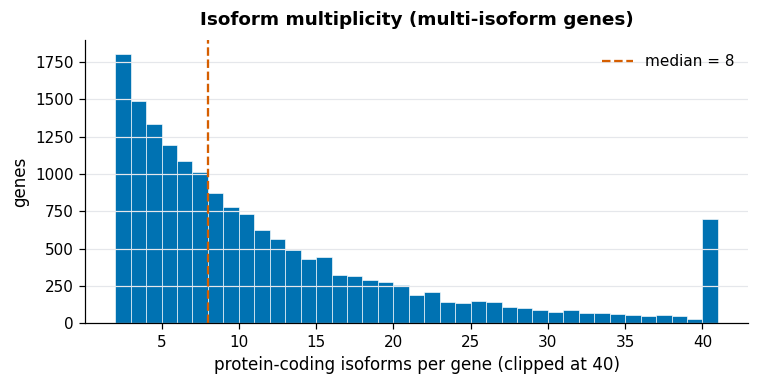

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(genes["n_isoforms"].clip(upper=40), bins=range(2, 42),
        color=COLORS["fastCDS"], edgecolor="white", linewidth=0.4)
m = genes["n_isoforms"].median()
ax.axvline(m, color=COLORS["bad"], ls="--", lw=1.5, label=f"median = {int(m)}")
ax.set(xlabel="protein-coding isoforms per gene (clipped at 40)",
       ylabel="genes", title="Isoform multiplicity (multi-isoform genes)")
ax.legend()
fig.tight_layout(); fig.savefig(str(CONS / "fig_isoform_multiplicity.png")); plt.show()

## Stages 1–3 — project every source domain and score conservation

`isoform_conservation.py` selects every Pfam domain that sits on a gene's source
isoform, projects it with fastCDS, maps every other isoform structure-only,
and computes `coverage` / `inframe_coverage` per `(domain, target)` pair. (Run
once; cached afterwards.)

In [4]:
step(CONS / "conservation_long.tsv", [
    PY, BENCH / "isoform_conservation.py",
    "--isoforms", CONS / "isoforms.tsv", "--genes", CONS / "genes.tsv",
    "--pfam-meta", DATA / "pfam_human_v115_meta.tsv",
    "--index", IDX, "--out", CONS / "conservation_long.tsv", "--threads", "6"])

con = pd.read_csv(CONS / "conservation_long.tsv", sep="\t")
print(f"(domain x target) pairs: {len(con):,}")
print((con["conservation_class"].value_counts(normalize=True) * 100).round(1).to_string())

# Domain-level conservation score + metadata join
atlas = pd.read_csv(DATA / "atlas_v115_by_domain.tsv", sep="\t",
                    usecols=["query_id", "domain_length_aa", "is_single_exon_domain",
                             "fclass", "protein_length_aa"])
g = con.groupby("query_id")
dom = pd.DataFrame({
    "n_targets": g.size(),
    "frac_conserved": g["conservation_class"].apply(lambda s: (s == "conserved").mean()),
    "mean_inframe": g["inframe_coverage"].mean(),
    "gene_name": g["gene_name"].first(),
    "pfam_id": g["pfam_id"].first(),
}).reset_index().merge(atlas, on="query_id", how="left")
print(f"domains scored: {len(dom):,}   median frac_conserved: {dom['frac_conserved'].median():.2f}")

cached: conservation_long.tsv


(domain x target) pairs: 505,361
conservation_class
conserved    75.8
lost         19.5
partial       4.6


domains scored: 43,601   median frac_conserved: 0.75


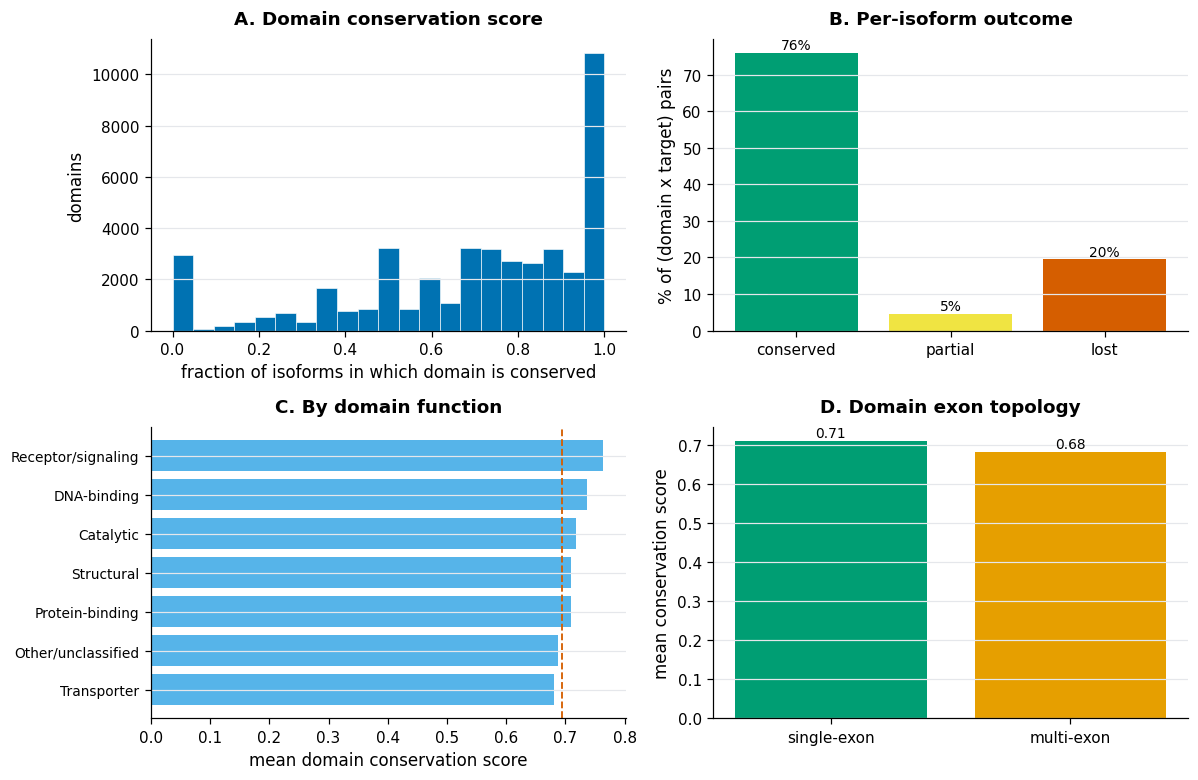

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7.2))

# A. domain-level conservation score
ax[0,0].hist(dom["frac_conserved"], bins=21, color=COLORS["fastCDS"], edgecolor="white", linewidth=0.4)
ax[0,0].set(xlabel="fraction of isoforms in which domain is conserved",
            ylabel="domains", title="A. Domain conservation score")

# B. pair-level class distribution
cc = con["conservation_class"].value_counts(normalize=True).reindex(["conserved","partial","lost"]) * 100
ax[0,1].bar(range(3), cc.values, color=[COLORS["good"], COLORS["highlight"], COLORS["bad"]])
ax[0,1].set_xticks(range(3)); ax[0,1].set_xticklabels(["conserved","partial","lost"])
ax[0,1].set(ylabel="% of (domain x target) pairs", title="B. Per-isoform outcome")
for i, v in enumerate(cc.values):
    ax[0,1].text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

# C. conservation by functional class
fc = dom.groupby("fclass")["frac_conserved"].mean().sort_values()
ax[1,0].barh(range(len(fc)), fc.values, color=COLORS["neutral"])
ax[1,0].set_yticks(range(len(fc))); ax[1,0].set_yticklabels(fc.index, fontsize=9)
ax[1,0].set(xlabel="mean domain conservation score", title="C. By domain function")
ax[1,0].axvline(dom["frac_conserved"].mean(), color=COLORS["bad"], ls="--", lw=1.2)

# D. single- vs multi-exon domains
se = dom.groupby("is_single_exon_domain")["frac_conserved"].mean().reindex([True, False])
ax[1,1].bar(range(2), se.values, color=[COLORS["good"], COLORS["transvar"]])
ax[1,1].set_xticks(range(2)); ax[1,1].set_xticklabels(["single-exon","multi-exon"])
ax[1,1].set(ylabel="mean conservation score", title="D. Domain exon topology")
for i, v in enumerate(se.values):
    ax[1,1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

fig.tight_layout(); fig.savefig(str(CONS / "fig_conservation_overview.png")); plt.show()

## Verification

Two guards on the engine:

1. **Self-projection** — a domain projected onto its *own* source isoform must
   score exactly `coverage = inframe_coverage = 1.0`.
2. **TP53 DBD** — the DNA-binding domain is p53's constitutive structural core,
   so it should be conserved across most TP53 isoforms.

In [ ]:
sys.path.insert(0, str(BENCH))
import isoform_conservation as ic

mp = fc.Mapper(str(IDX), threads=4)
src = mp.map_batch([dict(id="ENSP00000269305", aa_start=95, aa_end=289,
                         domain_id="TP53_DBD")], output="coding")
seg = src.cds_segments; seg = seg[seg.overlaps_domain == "coding_overlap"]
ddom = ic._segments(seg)["TP53_DBD"]
st = ic._structures(mp.map_batch([dict(id="ENSP00000269305", domain_id="ENSP00000269305")],
                                 output="isoform").isoform)["ENSP00000269305"]
bp, cov, inf = ic._score(ddom, st)
assert abs(cov/bp - 1.0) < 1e-9 and abs(inf/bp - 1.0) < 1e-9, "self-projection must be 1.0"
print(f"[1] self-projection TP53 DBD: coverage={cov/bp:.3f} inframe={inf/bp:.3f}  OK")

tp = dom[dom.gene_name == "TP53"][["query_id","pfam_id","frac_conserved","n_targets"]]
print("[2] TP53 Pfam domains across isoforms:")
print(tp.to_string(index=False))

## Summary

Builds the isoform universe and scores every source Pfam domain's conservation across the gene's alternative protein-coding isoforms (intact / partial / lost), the input for the manuscript Figure 1C-F panels (finalized separately). Exploratory mechanism / confounder / variant analyses are omitted.
